# Basal melt parameterisation analysis
[Finucane and Stewart (2024)](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024GL108196) present a parameterisation for basal melt of ice shelves based on bathymetric and hydrographic data. Let's see how much those estimates change with the different bathymetry products.

This notebook pretty much just implements the code presented in Garret's [repo](https://github.com/garrettdreyfus/geostrophic_basal_melt?tab=readme-ov-file).

In [1]:
import xarray as xr
import datetime

from scipy.ndimage import label 
import numpy as np
from tqdm import tqdm
import gsw,xarray, pyproj
import matplotlib.pyplot as plt
import numpy as np
import pickle
import matplotlib.colors as colors
import glob
from pathlib import Path


In [2]:
import dask.distributed as dask

client = dask.Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41267,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41933,Total threads: 1
Dashboard: /proxy/46007/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:44059,


In [3]:
import os
os.chdir('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
                'antarctic-bathymetry-project/geostrophic_basal_melt')

In [4]:
# import all the bits of code from basal melt repo
import bathtub as bt
import HUB
import woa
import paperfigures as pf
import cdw

In [5]:
#These flags just make it easy to turn off and steps of the analysis 
writeBedMach = True
writeShelfNumbers = True
writeHUB = True
writePolygons = True
writeGL = True
createWOA = True
createGISS = True
createClosestShelfPoints = True
createQuants = True
createSlopes = True

In [6]:
##################################################
#Create Polygon objects from MEASURES files
##################################################

if writePolygons:
    bt.save_polygons();

with open("data/shelfpolygons.pickle","rb") as f:
    shelf_polygons = pickle.load(f);

In [7]:
# shelf_polygons.keys()


In [8]:
def open_topog_file(short_name, data_dir = '/g/data/jk72/ed7737/access-om3/inputs/4km-PanAntarctic/bathy_products/'):
    """Quick and dirty function for opening the MOM6 topog files."""
    
    topog = xr.open_dataset(data_dir + short_name + '/topog.nc', chunks='auto')
    
    return topog

def write_topog_file(topog, short_name, data_dir = '/g/data/jk72/ed7737/access-om3/inputs/4km-PanAntarctic/bathy_products/'):
    """Quick and dirty function for opening the MOM6 topog files."""
    
    topog.to_netcdf(data_dir + short_name + '/topog_with_HUB.nc')
    
    return

def generateHUBs(depth,ice,resolution=5):
    #We don't care about the structure of the bathymetry off the shelf break for now
    # so we'll call the off shelf water the part that's greater than 2000 meters deep
    # and just set it to 2000 meters
    depth[depth<-2000] = -2000

    
    ## Grab a single point in the open ocean. We just made all the open ocean one depth so it is connected 
    openoceancoord = np.where(depth==-2000)
    openoceancoord = (openoceancoord[0][-1],openoceancoord[1][-1])

    ## Create the slices we'd like to search from -2000 to 0 using `resolution` provided in function call
    slices = - np.asarray(range(0,2000,resolution)[::-1])
    ## A matrix output we will fill with nans as we go.
    HUB = np.full_like(depth,np.nan)
    for iso_z in tqdm(slices):
        ### A mask that shows all points below our search depth that arent land or grounded ice.
        below = np.logical_and((depth<=iso_z),ice!=1)
        ### Use the image library label function to label connected regions.
        regions, _ = label(below)
        ### If any region is connected to open ocean at this depth and it hasn't been assigned a GLIB before (all ocean points are connected at z=0)
        ### then set it's glib to iso_z -20. The minus 20 is there because we are looking for the depth at which its not connected
        HUB[np.logical_and(regions==regions[openoceancoord],np.isnan(HUB))] = iso_z-resolution
    return HUB

In [9]:
topog_names = ['GEBCO24', 'GEBCO25', 'MEAN', 'DTU_DKL',
               'DTU_DNN', 'NCU_DNN', 'NRL_CNN', 'SRTM15_V2_7']

data_dir = '/g/data/jk72/ed7737/access-om3/inputs/4km-PanAntarctic/bathy_products/'

for name in topog_names:
    topog = open_topog_file(name)

    # Original code had icemask==0 in the ice regions, which hurt my brain, so I flipped it.
    icemask = xr.where(topog.depth>=10, 0, 1)
    icemask = icemask.where(topog.geolat_t<=-60, 0)
    icemask = icemask.values

    bedvalues = -topog.depth.values

    print("Calculating Hub for {0}".format(name))
    topog_hub = generateHUBs(bedvalues,icemask)
    
    topog['HUB'] = (('ny', 'nx'), topog_hub)

    today = datetime.datetime.today().strftime("%Y-%m-%d %H:%M")
    topog.attrs['history'] +='\n added highest unconnected isobath {0}'.format(today)
    
    topog.to_netcdf(data_dir + name + '/topog_with_HUB.nc')
    


Calculating Hub for GEBCO24


100%|██████████| 400/400 [00:18<00:00, 21.08it/s]


Calculating Hub for GEBCO25


100%|██████████| 400/400 [00:19<00:00, 20.99it/s]


Calculating Hub for MEAN


...

100%|██████████| 400/400 [00:18<00:00, 21.05it/s]


Calculating Hub for NRL_CNN


100%|██████████| 400/400 [00:19<00:00, 20.91it/s]


Calculating Hub for SRTM15_V2_7


100%|██████████| 400/400 [00:19<00:00, 20.63it/s]


In [9]:
files = sorted(glob.glob('/g/data/jk72/ed7737/access-om3/inputs/'+
                                    '4km-PanAntarctic/bathy_products/*/topog_with_HUB.nc'))

# get a coordinate for the new dimension
bathy_product=[]
for file in files:
    path_with_file = Path(file)
    bathy_product.append(path_with_file.parent.name)
    
topogs_with_hub = xr.open_mfdataset(files, chunks='auto',
                                    combine='nested', concat_dim='bathy_product',
                                   )

topogs_with_hub['bathy_product'] = sorted(bathy_product)

In [10]:



topogs_with_hub

<xarray.Dataset> Size: 997MB
Dimensions:            (bathy_product: 8, ny: 1442, nx: 4320)
Coordinates:
  * bathy_product      (bathy_product) <U11 352B 'DTU_DKL' ... 'SRTM15_V2_7'
Dimensions without coordinates: ny, nx
Data variables:
    depth              (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    sea_area_fraction  (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    geolon_t           (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    geolat_t           (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
    HUB                (bathy_product, ny, nx) float32 199MB dask.array<chunksize=(1, 1442, 4320), meta=np.ndarray>
Attributes:
    original_file:  topog_new_fillfraction_edited_deseas.nc
    input_file:     /g/data/vk83/prerelease/configurations/inputs/access-om3/...
    history:        Fri Jan 16 15:08:27 2026 +1100: topogtools min_max_depth ...

In [59]:
topogs_with_hub.to_netcdf('~/topogs_with_hub.nc')

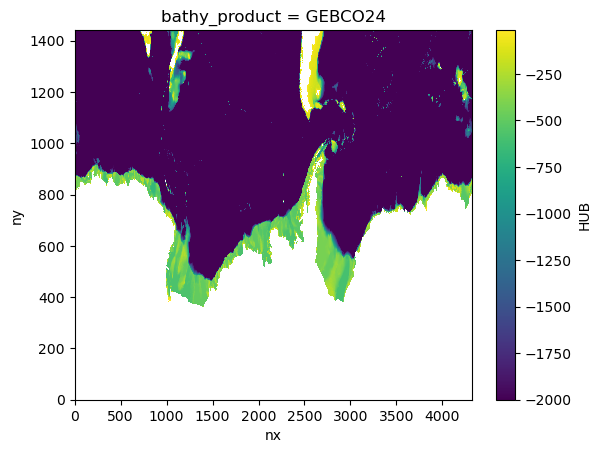

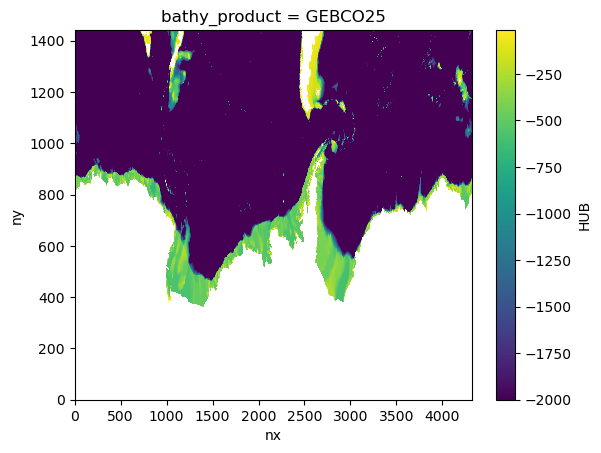

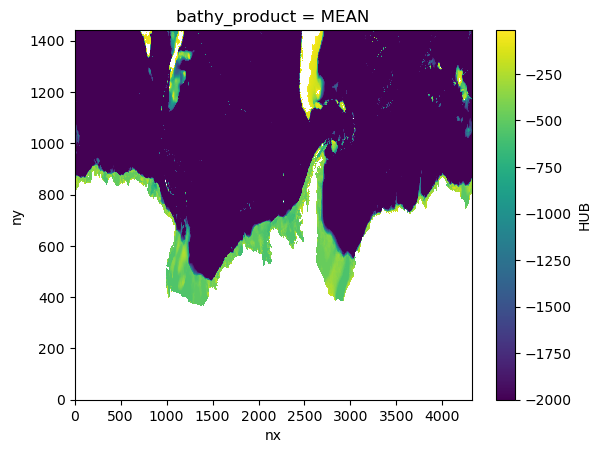

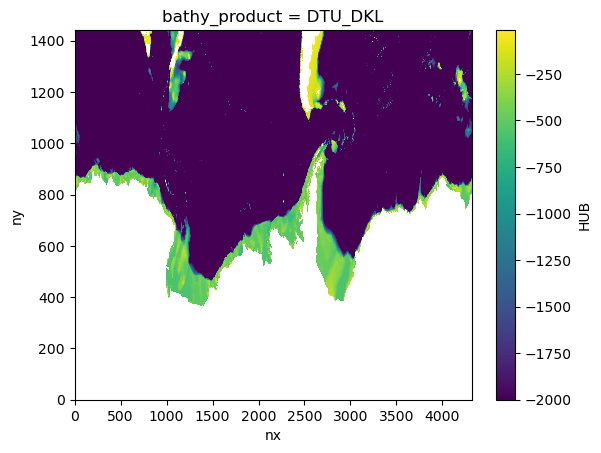

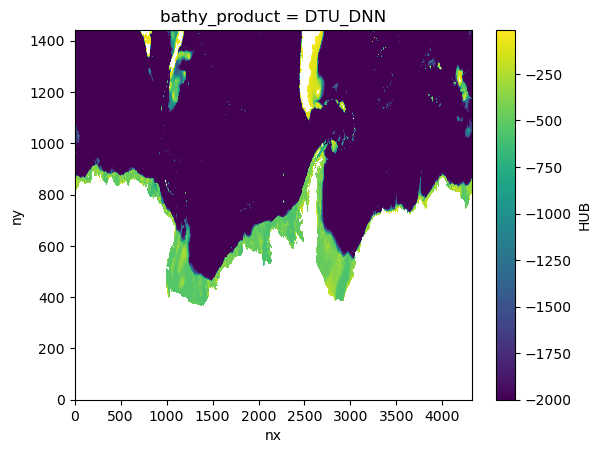

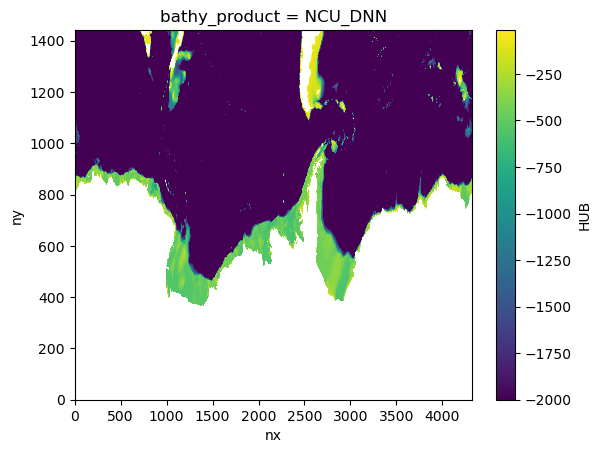

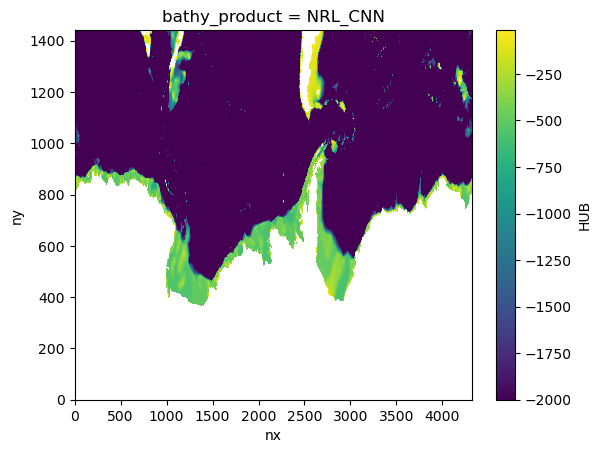

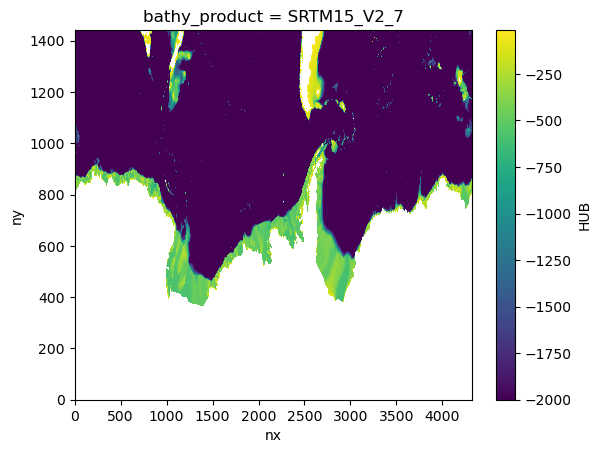

In [15]:
for name in topog_names:
    plt.figure()
    topogs_with_hub['HUB'].sel(bathy_product=name).plot()
    plt.savefig('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
            'antarctic-bathymetry-project/analysis/HUB-plots/{0}_HUB.png'.format(name),
            dpi=200, bbox_inches='tight')

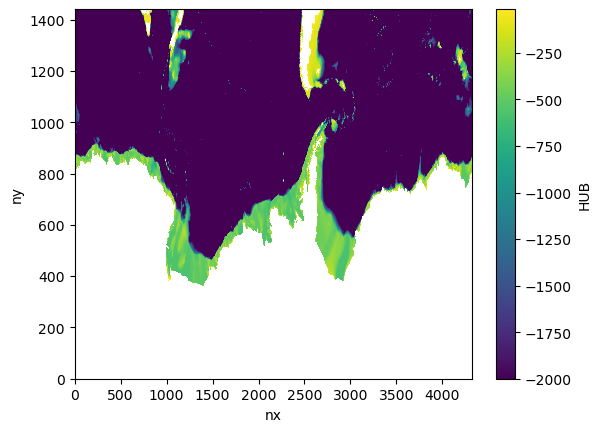

In [16]:
topogs_with_hub['HUB'].mean(dim='bathy_product').plot()

In [17]:
ML_topogs_HUB_std = topogs_with_hub['HUB'].sel(bathy_product=['DTU_DKL','DTU_DNN',
            'NCU_DNN', 'NRL_CNN']).std(dim='bathy_product')

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


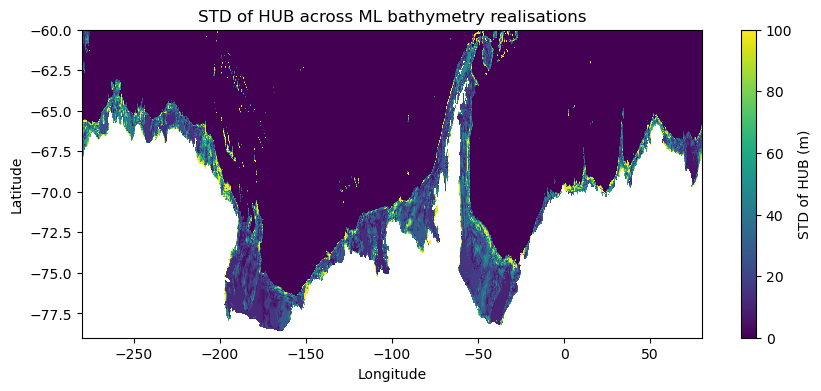

In [18]:
plt.figure(figsize=(10,4))
plt.pcolormesh(topogs_with_hub.sel(bathy_product='MEAN')['geolon_t'],
               topogs_with_hub.sel(bathy_product='MEAN')['geolat_t'],
               ML_topogs_HUB_std, vmin=0, vmax=100)

plt.ylim(-79, -60)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

CB = plt.colorbar()
CB.set_label('STD of HUB (m)')
plt.title('STD of HUB across ML bathymetry realisations')
plt.savefig('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
            'antarctic-bathymetry-project/analysis/ML_bathymetries_std_HUB.png',
            dpi=200, bbox_inches='tight')

In [19]:


all_topogs_HUB_std = topogs_with_hub['HUB'].sel(bathy_product=['GEBCO24', 'GEBCO25',
                'DTU_DKL', 'DTU_DNN', 'NCU_DNN', 'NRL_CNN',
                'SRTM15_V2_7']).std(dim='bathy_product')

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


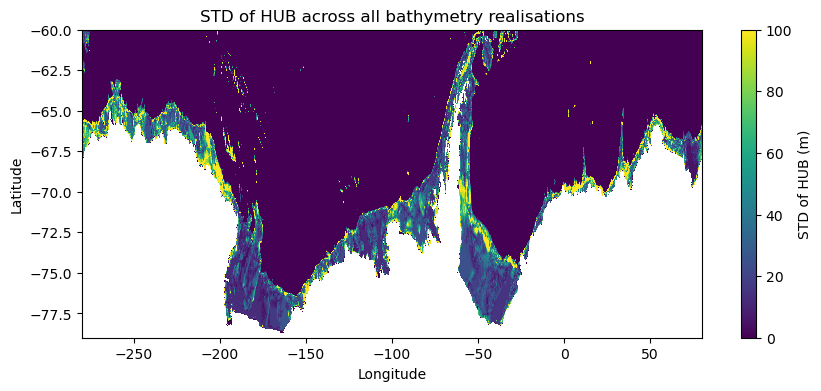

In [20]:
plt.figure(figsize=(10,4))
plt.pcolormesh(topogs_with_hub.sel(bathy_product='MEAN')['geolon_t'],
               topogs_with_hub.sel(bathy_product='MEAN')['geolat_t'],
               all_topogs_HUB_std, vmin=0, vmax=100)

plt.ylim(-79, -60)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

CB = plt.colorbar()
CB.set_label('STD of HUB (m)')
plt.title('STD of HUB across all bathymetry realisations')
plt.savefig('/home/552/ed7737/coding-and-projects/panant_bathy_ensemble/'+
            'antarctic-bathymetry-project/analysis/all_bathymetries_std_HUB.png',
            dpi=200, bbox_inches='tight')

# build a nearest ice shelf mask

In [60]:
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd

Shapefile columns: ['NAME', 'Regions', 'Subregions', 'TYPE', 'Asso_Shelf', 'geometry']
Shapefile CRS: EPSG:3031
Shelf bounds (m, EPSG:3031): [-2508074.68072635 -2143924.79330131  2745433.40095524  2241490.25787429]


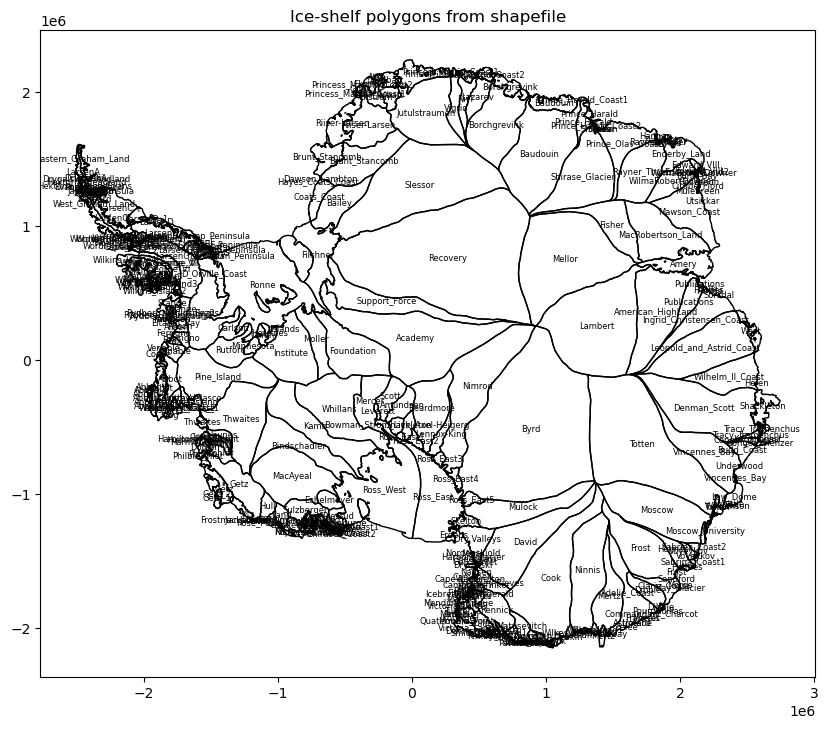

In [61]:
# 1) Load ice-shelf boundaries shapefile
shp_path = "../geostrophic_basal_melt/regions/IceBoundaries_Antarctica_v02.shp"
shelf = gpd.read_file(shp_path)
print("Shapefile columns:", shelf.columns.tolist())
print("Shapefile CRS:", shelf.crs)
print("Shelf bounds (m, EPSG:3031):", shelf.total_bounds)

# Quick plot of the shelf polygons (for sanity check)
label_size = 6  # adjust this to make labels smaller/larger
ax = shelf.plot(figsize=(10, 10), edgecolor="black", facecolor="none")
ax.set_title("Ice-shelf polygons from shapefile")

# Add labels (using polygon centroids)
# NOTE: This can be crowded; adjust label_size as needed.
shelf_centroids = shelf.copy()
shelf_centroids["centroid"] = shelf_centroids.geometry.centroid

# Pick the shelf-name column
shelf_name_col = "NAME"
for _, row in shelf_centroids.iterrows():
    if pd.notna(row[shelf_name_col]):
        ax.text(
            row["centroid"].x,
            row["centroid"].y,
            str(row[shelf_name_col]),
            fontsize=label_size,
            ha="center",
            va="center",
            clip_on=True,
        )

In [63]:
# 2) Load bathymetry dataset
ds = topogs_with_hub
print("Dataset variables:", list(ds.data_vars))
print("Dataset dimensions:", ds.dims)

# Choose a single bathymetry product for debugging
product = ds["bathy_product"].values[0]
print("Using bathy_product:", product)
ds_sel = ds.sel(bathy_product=product)

Dataset variables: ['depth', 'sea_area_fraction', 'geolon_t', 'geolat_t', 'HUB']
Dataset dimensions: FrozenMappingWarningOnValuesAccess({'bathy_product': 8, 'ny': 1442, 'nx': 4320})
Using bathy_product: DTU_DKL


In [64]:
# 3) Depth mask: XX to YY m
# NOTE: The depth is stored as a positive value.
depth = ds_sel["depth"]
depth_mask = (depth >= 100) & (depth <= 2500)

In [65]:
# 4) Extract lon/lat for masked points
lon = ds_sel["geolon_t"].values
lat = ds_sel["geolat_t"].values
lon_flat = lon.ravel()
lat_flat = lat.ravel()
mask_flat = depth_mask.values.ravel()
keep = np.isfinite(lon_flat) & np.isfinite(lat_flat) & mask_flat

print(f"Total grid points: {lon_flat.size}")
print(f"Points within depth mask: {keep.sum()}")
print("Depth range (m):", float(depth.min()), float(depth.max()))

# # Normalize longitudes to -180..180
# lon_flat = (lon_flat + 180) % 360 - 180
# print("Longitude range after normalization:", float(lon_flat[keep].min()), float(lon_flat[keep].max()))
# print("Latitude range:", float(lat_flat[keep].min()), float(lat_flat[keep].max()))

# Build GeoDataFrame of points to query
pts = gpd.GeoDataFrame(
    {"lon": lon_flat[keep], "lat": lat_flat[keep]},
    geometry=gpd.points_from_xy(lon_flat[keep], lat_flat[keep]),
    crs="EPSG:4326",
)
print("Points bounds (deg):", pts.total_bounds)

# Reproject points to match shapefile CRS
pts_proj = pts.to_crs(shelf.crs)
print("Points bounds (m, EPSG:3031):", pts_proj.total_bounds)

print("Shelf bounds (m):", shelf.total_bounds)

# Quick sanity check: do these bounds overlap?
pts_bounds = pts_proj.total_bounds
shelf_bounds = shelf.total_bounds
print("Overlap in x?:", not (pts_bounds[2] < shelf_bounds[0] or pts_bounds[0] > shelf_bounds[2]))
print("Overlap in y?:", not (pts_bounds[3] < shelf_bounds[1] or pts_bounds[1] > shelf_bounds[3]))

Total grid points: 6229440
Points within depth mask: 594298
Depth range (m): 10.432805061340332 5808.65673828125
Points bounds (deg): [-279.95834351  -78.59880829   79.95833588  -37.49578094]
Points bounds (m, EPSG:3031): [-6107904.50902646 -6124285.91802878  6025881.59847772  6118780.65938472]
Shelf bounds (m): [-2508074.68072635 -2143924.79330131  2745433.40095524  2241490.25787429]
Overlap in x?: True
Overlap in y?: True


In [71]:
# 5) Assign nearest ice shelf (skip points > 1000 km away)
# NOTE: Many points are far offshore; a large max_distance causes "closest" shelf to be very far.
#       We keep the distance threshold reasonable and will check how many points are left unassigned.
max_distance_km = 500
max_distance_m = max_distance_km * 1000

# Dissolve shelf geometries by name to avoid splitting a single shelf into multiple polygons.
shelf_dissolved = shelf.dissolve(by=shelf_name_col).reset_index()

# Run the full nearest-neighbor assignment for all points within the depth mask.
# (~110k points in our mask; this is feasible in memory.)
nearest = gpd.sjoin_nearest(
    pts_proj,
    shelf_dissolved[[shelf_name_col, "geometry"]],
    how="left",
    distance_col="dist_m",
    max_distance=max_distance_m,
)

# Ensure the output aligns 1:1 with pts_proj (drop any duplicated indices if they occur)
if nearest.index.duplicated().any():
    dup_count = nearest.index.duplicated().sum()
    print(f"Warning: {dup_count} duplicated point indices in nearest join; keeping first occurrence.")
    nearest = nearest[~nearest.index.duplicated(keep="first")]

print(f"Total points (depth mask): {len(pts_proj)}")
print(f"Nearest output rows: {len(nearest)}")
print(f"Points assigned to a shelf (within {max_distance_km} km):", nearest[shelf_name_col].notna().sum())
print(f"Unassigned points (beyond {max_distance_km} km):", nearest[shelf_name_col].isna().sum())
print(f"Unique shelves assigned: {len(nearest[shelf_name_col].dropna().unique())}")
print("Distances (km) stats (assigned points):", nearest.loc[nearest[shelf_name_col].notna(), "dist_m"].describe() / 1000)

Total points (depth mask): 594298
Nearest output rows: 594298
Points assigned to a shelf (within 500 km): 423239
Unassigned points (beyond 500 km): 171059
Unique shelves assigned: 233
Distances (km) stats (assigned points): count    423.239000
mean     129.206580
std      108.824006
min        0.000000
25%       42.719860
50%      100.153437
75%      187.511579
max      499.998593
Name: dist_m, dtype: float64


In [72]:
# 6) Convert shelf names to numbers (for mapping back to grid)
unique_shelves = sorted(nearest[shelf_name_col].dropna().unique())
shelf_to_num = {name: i for i, name in enumerate(unique_shelves)}
num_to_shelf = {i: name for name, i in shelf_to_num.items()}
print("Shelf mapping (sample):", dict(list(shelf_to_num.items())[:10]))

Shelf mapping (sample): {'Abbot': 0, 'Abbot_1': 1, 'Abbot_2': 2, 'Abbot_4': 3, 'Abbot_5': 4, 'Abbot_6': 5, 'Adelie_Coast': 6, 'Ainsworth': 7, 'Alison': 8, 'Amery': 9}


In [73]:
# 7) Map back to numeric grid array (full grid)
keep_idx = np.flatnonzero(keep)
print("Keep index length:", len(keep_idx), "Nearest rows:", len(nearest))

shelf_array = np.full(lon_flat.shape, np.nan, dtype=float)

# Ensure nearest results align with keep indices.
if len(nearest) != len(keep_idx):
    raise ValueError(f"Mismatch between kept points ({len(keep_idx)}) and nearest join results ({len(nearest)}).")

numeric_values = [shelf_to_num.get(name, np.nan) for name in nearest[shelf_name_col].values]

shelf_array[keep_idx] = numeric_values

# Reshape into 2D grid (ny, nx)
ny, nx = lon.shape
shelf_array = shelf_array.reshape((ny, nx))

shelf_da = xr.DataArray(
    shelf_array,
    dims=["ny", "nx"],
    coords={"geolat_t": ds_sel["geolat_t"], "geolon_t": ds_sel["geolon_t"]},
)

print("Finished building shelf_da:", shelf_da.shape)
assigned_mask = np.isfinite(shelf_da.values)
print("Assigned points:", int(assigned_mask.sum()), "(%.1f%% of masked points)" % (assigned_mask.sum()/keep.sum()*100))

# Print the top 10 most frequent shelf codes
vals, counts = np.unique(shelf_da.values[assigned_mask], return_counts=True)
sorted_ix = np.argsort(counts)[::-1]
print("Top 10 assigned shelves (code, count, name):")
for i in sorted_ix[:10]:
    code = int(vals[i])
    print(f"  {code}: {counts[i]} -> {num_to_shelf.get(code, '<unknown>')}")


Keep index length: 594298 Nearest rows: 594298
Finished building shelf_da: (1442, 4320)
Assigned points: 423239 (71.2% of masked points)
Top 10 assigned shelves (code, count, name):
  93: 59814 -> Islands
  169: 31160 -> Ross_West
  166: 27751 -> Ronne
  203: 24421 -> Victoria_Land2
  105: 17061 -> LarsenD
  213: 15330 -> West_Graham_Land
  28: 14371 -> Coats_Coast
  168: 13671 -> Ross_East
  18: 13260 -> Brunt_Stancomb
  0: 11165 -> Abbot


In [74]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


Text(0.5, 1.0, 'Shelf assignments and ice-shelf polygons')

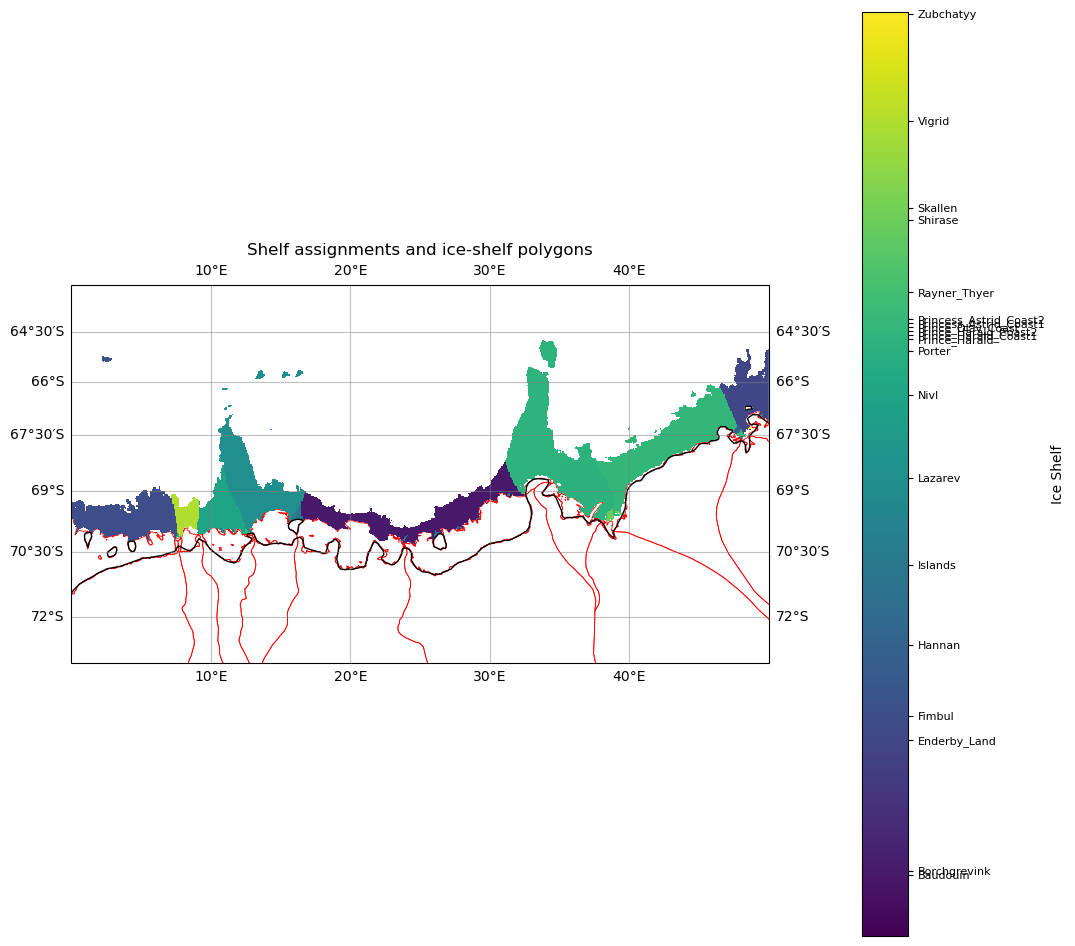

In [75]:
# --- Summary plot (0-50E, 63-70S) ---
region_lon = (0, 50)
region_lat = (-73, -63)

proj = ccrs.Mercator()  # or PlateCarree() if you prefer lat/lon

# Get the actual lon/lat values for comparison (handle 2D coordinates)
lon_2d = shelf_da['geolon_t'].values
lat_2d = shelf_da['geolat_t'].values

# Create mask for the region of interest
region_mask = ((lon_2d >= region_lon[0]) & 
               (lon_2d <= region_lon[1]) &
               (lat_2d >= region_lat[0]) & 
               (lat_2d <= region_lat[1]))

# Find which shelf codes actually exist in the full shelf_da where the region mask is True
region_shelf_codes = sorted([int(code) for code in np.unique(shelf_da.values[region_mask]) 
                             if np.isfinite(code)])
region_shelf_names = [num_to_shelf[code] for code in region_shelf_codes]

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 1, 1, projection=proj)

# Set extent in PlateCarree lon/lat
ax.set_extent([region_lon[0], region_lon[1], region_lat[0], region_lat[1]], crs=ccrs.PlateCarree())

# background
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.5)

# Plot shelf polygons (in PlateCarree)
shelf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.6,
        transform=ccrs.SouthPolarStereo(true_scale_latitude=-71))

# Plot shelf assignments with pcolormesh
im = ax.pcolormesh(shelf_da['geolon_t'],
                    shelf_da['geolat_t'],
                    shelf_da,
                   vmin=0, vmax=len(num_to_shelf),
                   transform=ccrs.PlateCarree())

# Create colorbar with only the ice shelf names in the region
cbar = plt.colorbar(im, ax=ax, pad=0.1, shrink=1.0, orientation='vertical')
cbar.set_label('Ice Shelf', fontsize=10)

# Set colorbar ticks to match shelf codes present in region
if region_shelf_codes:
    cbar.set_ticks([code + 0.5 for code in region_shelf_codes])
    cbar.set_ticklabels(region_shelf_names, fontsize=8)

ax.set_title('Shelf assignments and ice-shelf polygons')


Text(0.5, 1.0, 'Shelf assignments and ice-shelf polygons')

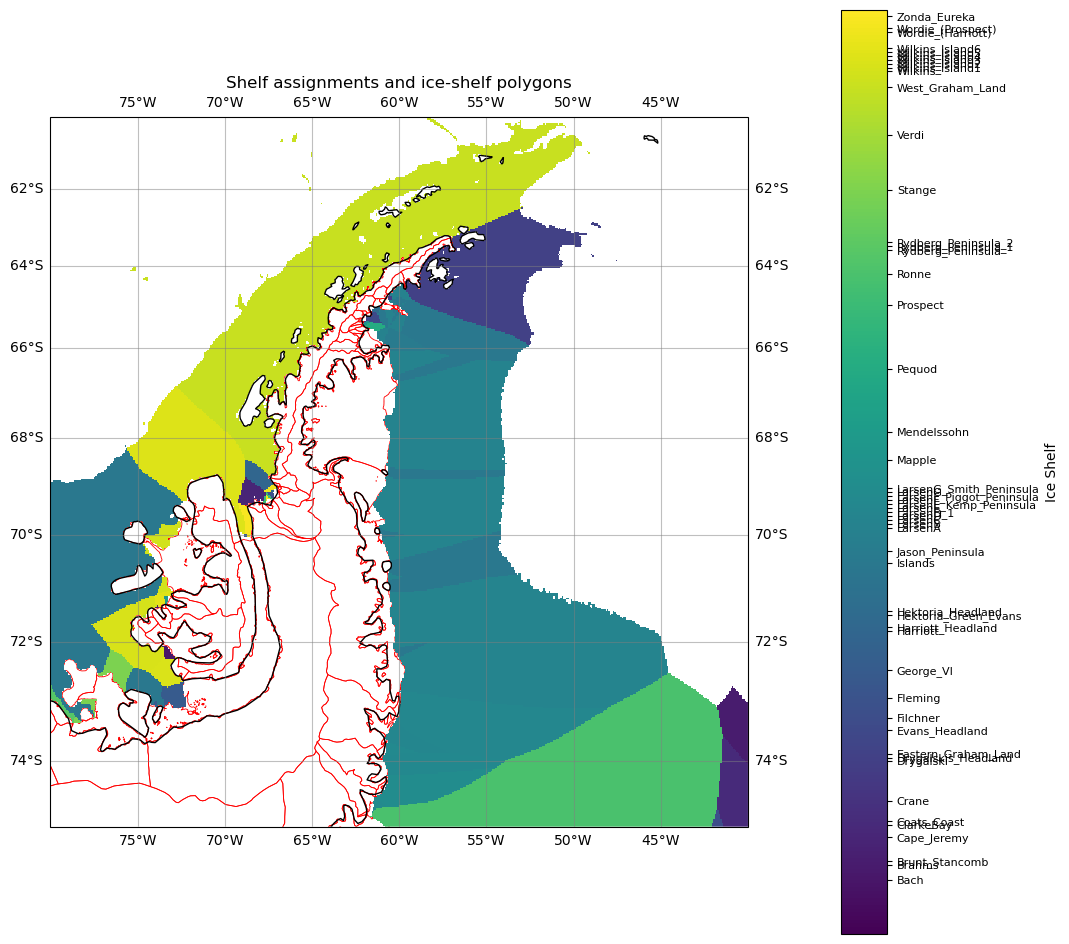

In [76]:
# --- Summary plot (80-40W, 75-60S) ---
# Note: longitude is wrapped from -280 to 80, so -80 to -40 is directly usable
region_lon = (-80, -40)
region_lat = (-75, -60)

proj = ccrs.Mercator()  # or PlateCarree() if you prefer lat/lon

# Get the actual lon/lat values for comparison (handle 2D coordinates)
lon_2d = shelf_da['geolon_t'].values
lat_2d = shelf_da['geolat_t'].values

# Create mask for the region of interest
region_mask = ((lon_2d >= region_lon[0]) & 
               (lon_2d <= region_lon[1]) &
               (lat_2d >= region_lat[0]) & 
               (lat_2d <= region_lat[1]))

# Find which shelf codes actually exist in the full shelf_da where the region mask is True
region_shelf_codes = sorted([int(code) for code in np.unique(shelf_da.values[region_mask]) 
                             if np.isfinite(code)])
region_shelf_names = [num_to_shelf[code] for code in region_shelf_codes]

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 1, 1, projection=proj)

# Set extent in PlateCarree lon/lat
ax.set_extent([region_lon[0], region_lon[1], region_lat[0], region_lat[1]], crs=ccrs.PlateCarree())

# background
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.5)

# Plot shelf polygons (in PlateCarree)
shelf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.6,
        transform=ccrs.SouthPolarStereo(true_scale_latitude=-71))

# Plot shelf assignments with pcolormesh
im = ax.pcolormesh(shelf_da['geolon_t'],
                    shelf_da['geolat_t'],
                    shelf_da,
                   vmin=0, vmax=len(num_to_shelf),
                   transform=ccrs.PlateCarree())

# Create colorbar with only the ice shelf names in the region
cbar = plt.colorbar(im, ax=ax, pad=0.1, shrink=1.0, orientation='vertical')
cbar.set_label('Ice Shelf', fontsize=10)

# Set colorbar ticks to match shelf codes present in region
if region_shelf_codes:
    cbar.set_ticks([code + 0.5 for code in region_shelf_codes])
    cbar.set_ticklabels(region_shelf_names, fontsize=8)

ax.set_title('Shelf assignments and ice-shelf polygons')
